In [8]:
!pip install efficientnet_pytorch

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from PIL import Image
import json
import requests
from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

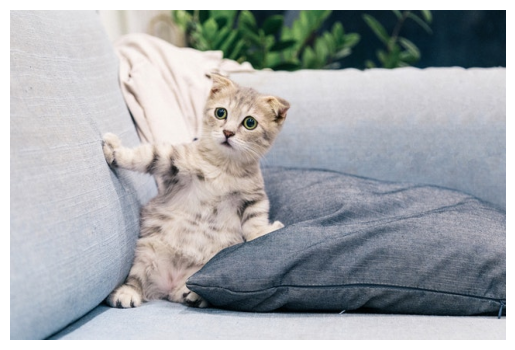

In [9]:
image_path = "/content/"
image = Image.open(image_path + "01.jpg")
plt.imshow(image)
plt.axis("off")  # 축 제거
plt.show()

Loaded pretrained weights for efficientnet-b0
Egyptian_cat: 46.60%
lynx: 10.29%
tabby: 4.45%
tiger_cat: 3.83%
Persian_cat: 2.07%


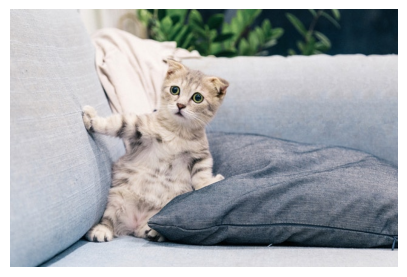

In [10]:
#ImageNet 클래스 매핑
imagenet_json_path = "/content/imagenet.json"

with open(imagenet_json_path, "r") as f:
    imagenet_classes = json.load(f)

#모델 로드
model = EfficientNet.from_pretrained('efficientnet-b0')
model.eval()


def preprocess_image(image_path, image_size):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  #사이즈 맞게 정리
    ])

    image = Image.open(image_path).convert('RGB')  #PIL 이미지로 변환
    image = transform(image)
    image = image.unsqueeze(0)  #배치 차원 수정

    return image

#추론 함수
def inference(model, image_path):
    image_size = model._conv_stem.weight.shape[2]
    input_tensor = preprocess_image(image_path, image_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    input_tensor = input_tensor.to(device)

    # 추론 수행
    with torch.no_grad():
        output = model(input_tensor)

    # 결과 해석
    probabilities = torch.nn.functional.softmax(output[0], dim=0)  # 소프트맥스 적용
    top5_prob, top5_catid = torch.topk(probabilities, 5)  # 상위 5개 클래스 추출

    for i in range(5):
        class_idx = str(top5_catid[i].item())
        class_name = imagenet_classes[class_idx][1]
        print(f"{class_name}: {top5_prob[i].item() * 100:.2f}%")

    # 원본 이미지 출력
    image = Image.open(image_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# 실행
inference(model, image_path+"01.jpg")


Loafer: 29.05%
clog: 20.91%
running_shoe: 20.76%
cowboy_boot: 2.17%
sandal: 2.13%


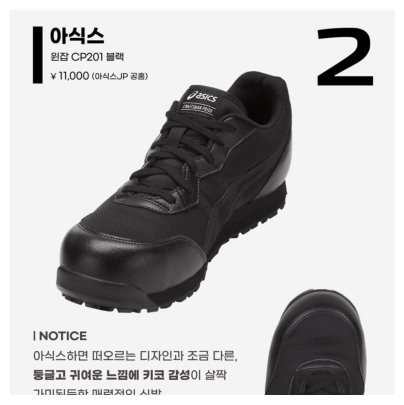

In [11]:
inference(model, image_path+"02.jpg")

In [12]:
model = EfficientNet.from_pretrained('efficientnet-b7')
model.eval()

Loaded pretrained weights for efficientnet-b7


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        64, 16, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        16, 64, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False
  

Ibizan_hound: 29.76%
Eskimo_dog: 24.50%
Siberian_husky: 4.99%
English_setter: 1.84%
Saluki: 1.81%


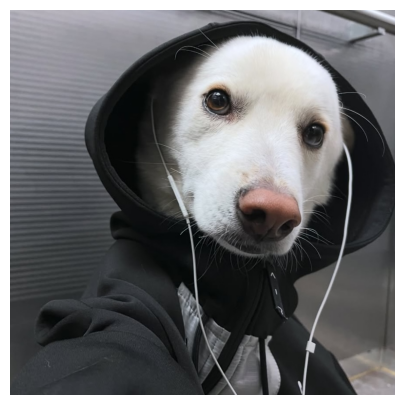

In [13]:
inference(model, image_path+"03.jpg")